## Data Preprocessing

5 minute price data for the past 2 years was retrieved from Alpaca Markets (https://alpaca.markets/). 

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mplfinance as mpf

In [2]:
# load 5M price data for each stock
files = {
    "COIN": "COIN_5min_2yr.csv",
    "NVDA": "NVDA_5min_2yr.csv",
    "OKLO": "OKLO_5min_2yr.csv",
    "PLTR": "PLTR_5min_2yr.csv",
    "TSLA": "TSLA_5min_2yr.csv",
}

# combine all 5 stock price data into one df
dfs = []
for sym, path in files.items():
    d = pd.read_csv(path, parse_dates=["timestamp"])
    d["symbol"] = sym
    dfs.append(d)

raw = pd.concat(dfs, ignore_index=True)

print("Combined shape:", raw.shape)
print("Symbols:", raw["symbol"].value_counts())
print(raw.head())
print(raw.tail())

Combined shape: (401473, 9)
Symbols: symbol
NVDA    81536
TSLA    81536
PLTR    81523
COIN    81506
OKLO    75372
Name: count, dtype: int64
  symbol                 timestamp     open      high     low     close  \
0   COIN 2024-02-28 17:00:00+00:00  210.435  211.2000  208.38  211.2000   
1   COIN 2024-02-28 17:05:00+00:00  211.166  211.6300  210.38  210.8750   
2   COIN 2024-02-28 17:10:00+00:00  210.770  211.1950  209.25  211.0379   
3   COIN 2024-02-28 17:15:00+00:00  211.040  211.4599  207.80  207.8900   
4   COIN 2024-02-28 17:20:00+00:00  207.960  209.0000  206.50  206.7100   

     volume  trade_count        vwap  
0  434465.0       5272.0  209.858263  
1  238866.0       4011.0  211.133156  
2  258458.0       3356.0  210.383626  
3  296406.0       4428.0  209.852641  
4  334472.0       4715.0  207.499718  
       symbol                 timestamp    open     high     low     close  \
401468   TSLA 2026-02-27 16:25:00+00:00  402.71  402.900  402.00  402.2800   
401469   TSLA 2026-

### Data Cleaning & Exploratory Data Analysis

In [3]:
# filter for only active trading hours 9:30 - 4PM Eastern Time
REGULAR_SESSION_ONLY = True
TZ_LOCAL = "America/New_York"

df = raw.copy()

# check timestamps
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
bad_ts = df["timestamp"].isna().sum()
if bad_ts:
    print("bad timestamps:", bad_ts)

# convert to eastern time
df["ts_ny"] = df["timestamp"].dt.tz_convert(TZ_LOCAL)

# sort by stock and timestamp
df = df.sort_values(["symbol", "timestamp"]).reset_index(drop=True)

# ensure we don't have duplicates
dup = df.duplicated(subset=["symbol", "timestamp"]).sum()
print("duplicate (symbol,timestamp):", dup)
if dup:
    df = df.drop_duplicates(subset=["symbol", "timestamp"], keep="last").reset_index(drop=True)

# filter for active trading hours 9:30 - 16:00
df["date_ny"] = df["ts_ny"].dt.date
df["time_ny"] = df["ts_ny"].dt.time

if REGULAR_SESSION_ONLY:
    mask = (df["ts_ny"].dt.hour > 9) | ((df["ts_ny"].dt.hour == 9) & (df["ts_ny"].dt.minute >= 30))
    mask &= (df["ts_ny"].dt.hour < 16)
    before = len(df)
    df = df.loc[mask].reset_index(drop=True)
    print(f"regular session rows kept: {len(df)} / {before}")

# check date range
print("min timestamp:", df["timestamp"].min())
print("max timestamp:", df["timestamp"].max())

# review records of each stock
for sym in sorted(df["symbol"].unique()):
    d = df[df["symbol"] == sym]
    print(f"\n{sym} head:")
    print(d.head(2))
    print(f"{sym} tail:")
    print(d.tail(2))

duplicate (symbol,timestamp): 0
regular session rows kept: 171812 / 401473
min timestamp: 2024-02-28 16:50:00+00:00
max timestamp: 2026-02-27 16:55:00+00:00

COIN head:
  symbol                 timestamp     open    high     low    close  \
0   COIN 2024-02-28 17:00:00+00:00  210.435  211.20  208.38  211.200   
1   COIN 2024-02-28 17:05:00+00:00  211.166  211.63  210.38  210.875   

     volume  trade_count        vwap                     ts_ny     date_ny  \
0  434465.0       5272.0  209.858263 2024-02-28 12:00:00-05:00  2024-02-28   
1  238866.0       4011.0  211.133156 2024-02-28 12:05:00-05:00  2024-02-28   

    time_ny  
0  12:00:00  
1  12:05:00  
COIN tail:
      symbol                 timestamp     open    high    low    close  \
35874   COIN 2026-02-27 16:50:00+00:00  176.960  178.20  176.9  177.770   
35875   COIN 2026-02-27 16:55:00+00:00  177.855  177.96  177.1  177.195   

         volume  trade_count        vwap                     ts_ny  \
35874  130211.0       1746.0  

In [4]:
# check price data completeness for each stock
day_coverage = (
    df.groupby(["symbol", "date_ny"])["ts_ny"]
      .agg(first="min", last="max", bars="count")
      .reset_index()
)
print(day_coverage.head(10))

# regular trading hours has about 78 5 minute candles
fullish = day_coverage["bars"] >= 75

print("\nFull trading days per stock:")
print(day_coverage.groupby("symbol")["bars"].apply(lambda s: (s >= 75).sum()).sort_values(ascending=False))
print("\nTotal full trading day rows:", fullish.sum(), "out of", len(day_coverage))

  symbol     date_ny                     first                      last  bars
0   COIN  2024-02-28 2024-02-28 12:00:00-05:00 2024-02-28 15:55:00-05:00    48
1   COIN  2024-02-29 2024-02-29 09:30:00-05:00 2024-02-29 15:55:00-05:00    78
2   COIN  2024-03-01 2024-03-01 09:30:00-05:00 2024-03-01 15:55:00-05:00    78
3   COIN  2024-03-04 2024-03-04 09:30:00-05:00 2024-03-04 15:55:00-05:00    78
4   COIN  2024-03-05 2024-03-05 09:30:00-05:00 2024-03-05 15:55:00-05:00    78
5   COIN  2024-03-06 2024-03-06 09:30:00-05:00 2024-03-06 15:55:00-05:00    78
6   COIN  2024-03-07 2024-03-07 09:30:00-05:00 2024-03-07 15:55:00-05:00    78
7   COIN  2024-03-08 2024-03-08 09:30:00-05:00 2024-03-08 15:55:00-05:00    78
8   COIN  2024-03-11 2024-03-11 09:30:00-04:00 2024-03-11 15:55:00-04:00    78
9   COIN  2024-03-12 2024-03-12 09:30:00-04:00 2024-03-12 15:55:00-04:00    78

Full trading days per stock:
symbol
COIN    453
OKLO    442
PLTR    423
NVDA    421
TSLA    420
Name: bars, dtype: int64

Total fu

It's important to note that the total number of full trading days is counting across all 5 stocks. This is not unique trading days across the market.

To visualize financial data, the following mplfinance package will be utilized.

https://github.com/matplotlib/mplfinance

In [5]:
# function to plot 2 year price data as candle stick charts
def plot_daily(symbol, df):
    d = df[df["symbol"] == symbol].copy()
    d["ts_ny"] = pd.to_datetime(d["ts_ny"])
    d = d.set_index("ts_ny").sort_index()
    daily = d.resample("1D").agg({
        "open": "first",
        "high": "max",
        "low": "min",
        "close": "last",
        "volume": "sum"
    }).dropna()

    mc = mpf.make_marketcolors(up="green", down="red", edge="inherit", wick="inherit", volume="inherit")
    style = mpf.make_mpf_style(marketcolors=mc, gridstyle="-")

    mpf.plot(
        daily, type="candle", volume=True, style=style,
        title=f"{symbol} — Daily (Regular Trading Hours Only)",
        ylabel="Price", ylabel_lower="Volume", figsize=(14, 7), tight_layout=True
    )

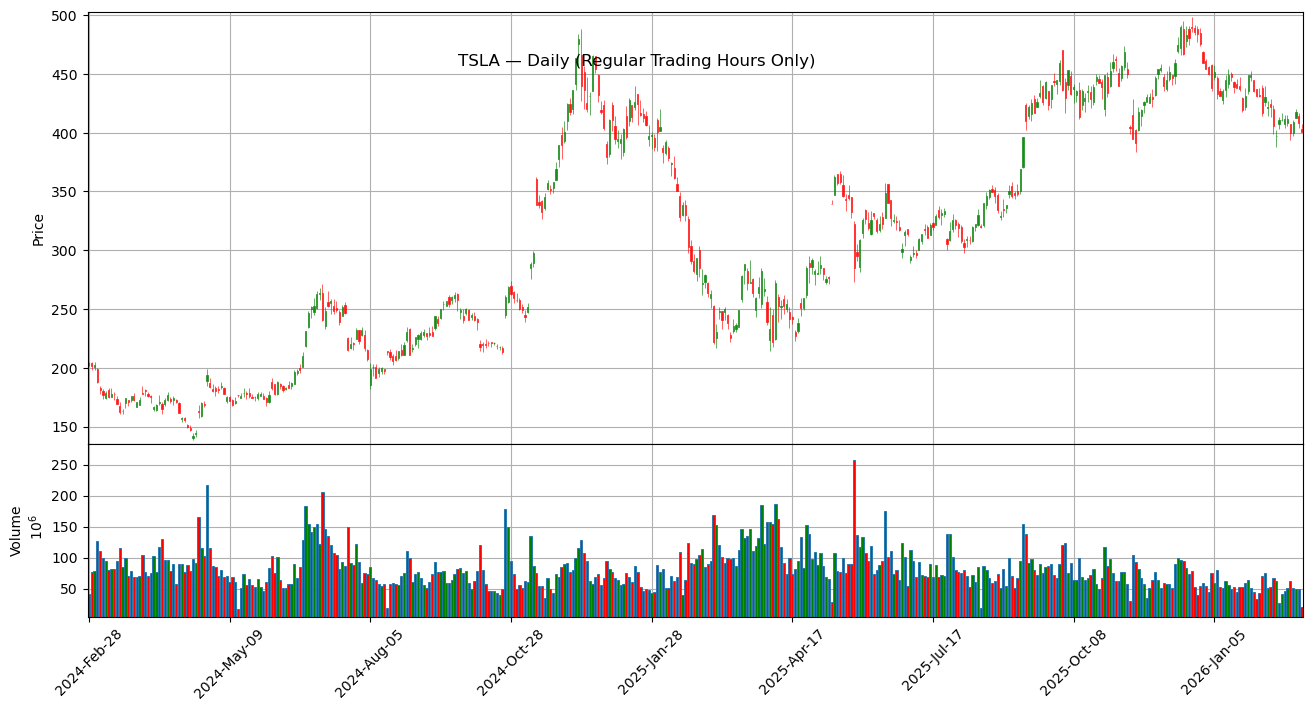

In [6]:
plot_daily("TSLA", df)

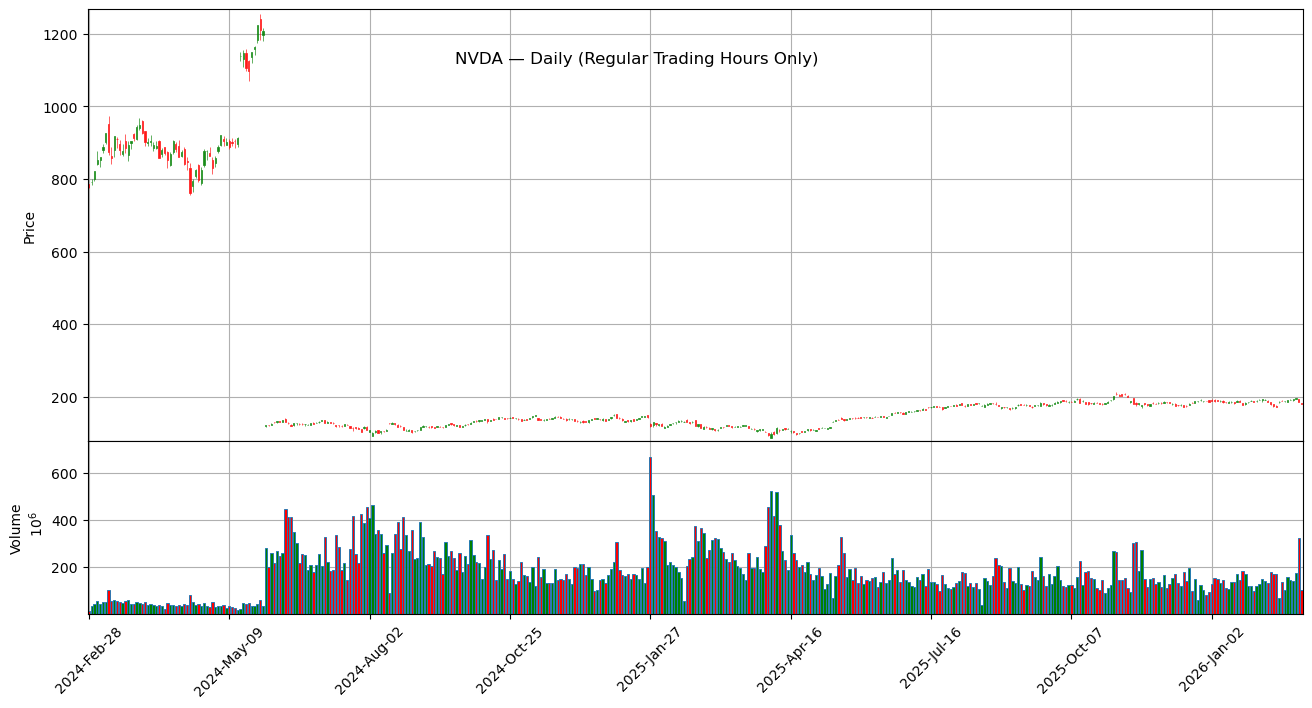

In [7]:
plot_daily("NVDA", df)

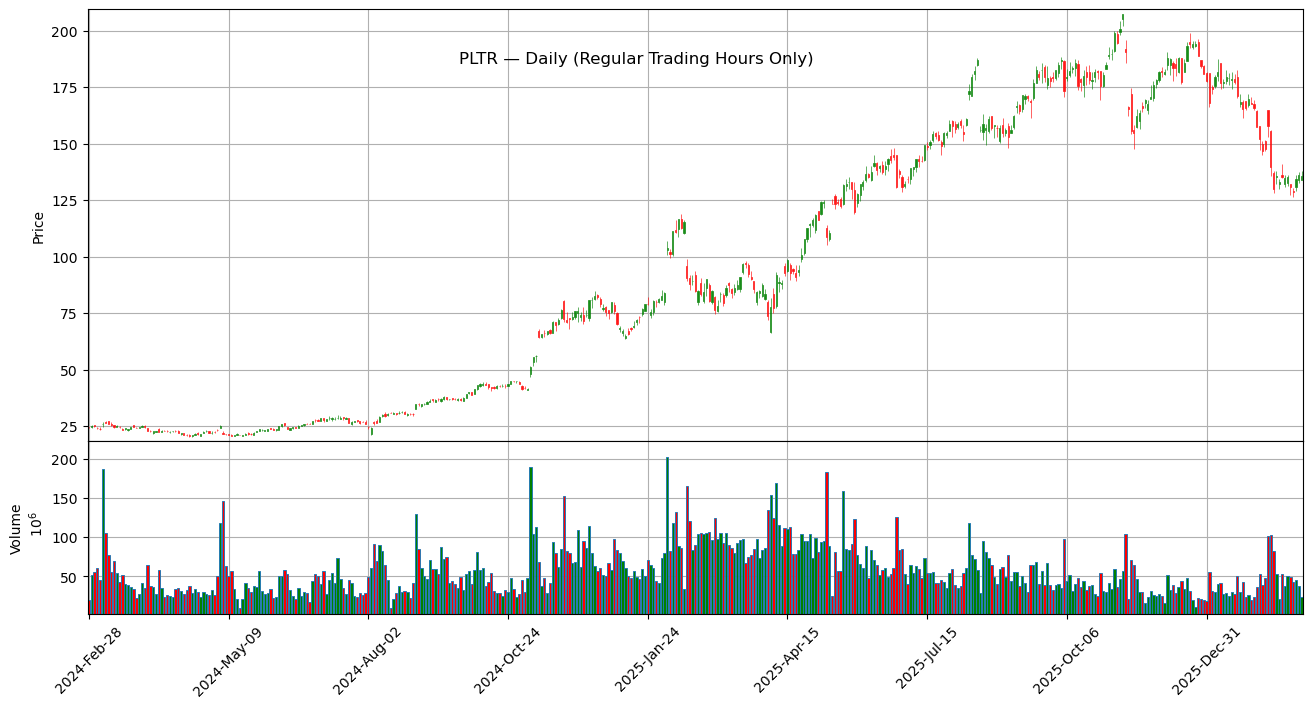

In [8]:
plot_daily("PLTR", df)

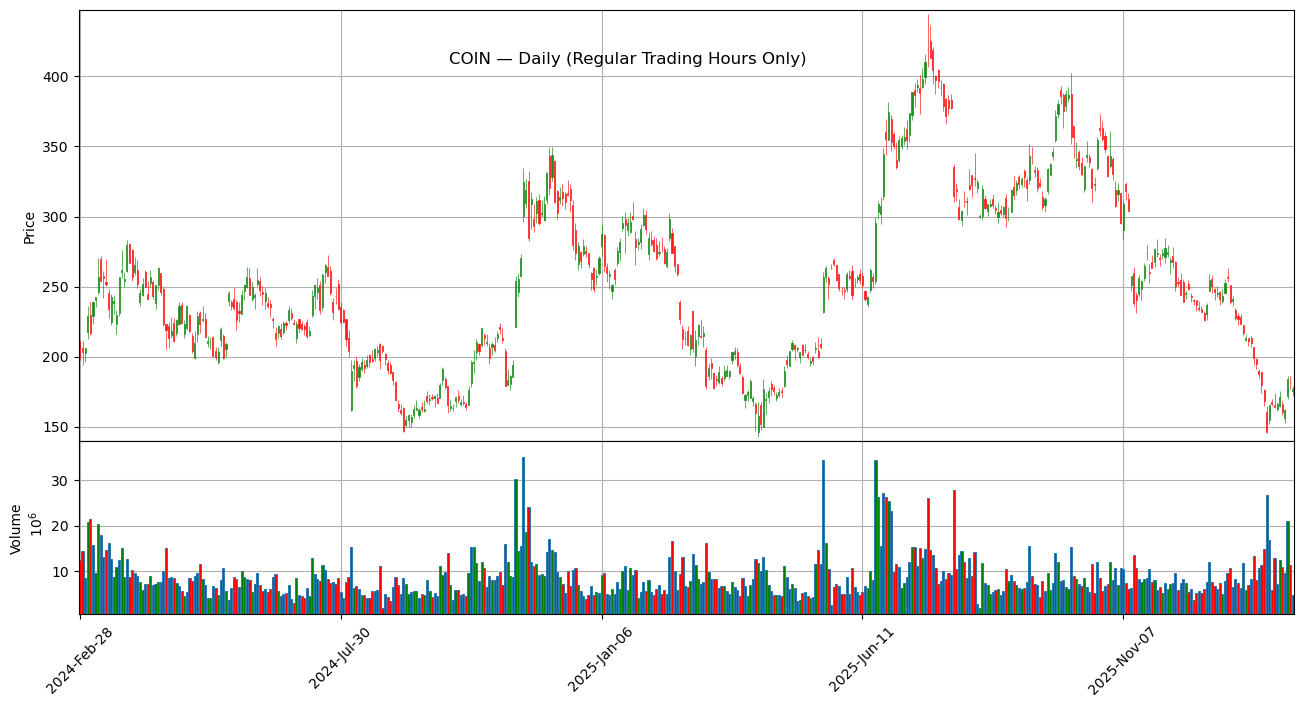

In [9]:
plot_daily("COIN", df)

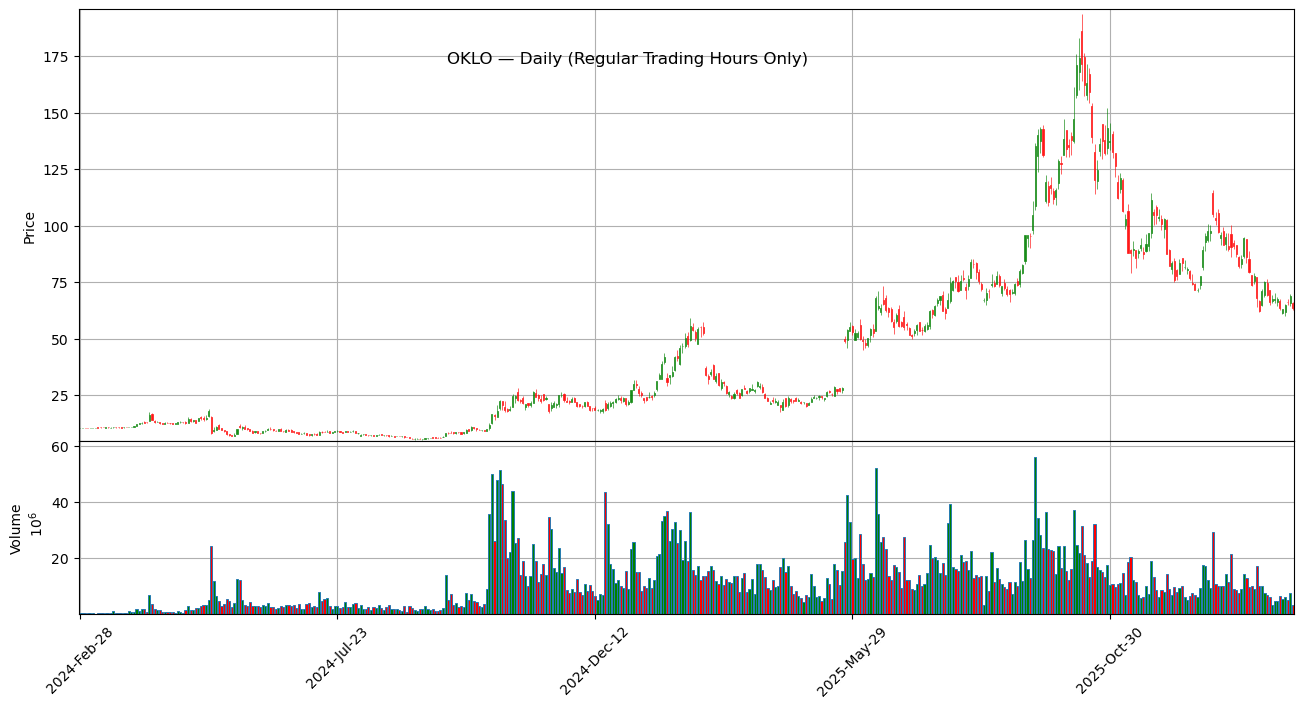

In [10]:
plot_daily("OKLO", df)

In [11]:
# save cleaned 5M RTH dataset
rth_cols = [
    "symbol","timestamp","ts_ny","date_ny",
    "open","high","low","close","volume","trade_count","vwap"
]

df_rth = df[rth_cols].copy()

df_rth.to_csv("multiasset_5m_rth_only.csv", index=False)

print("Saved: multiasset_5m_rth_only.csv")
print("Rows:", len(df_rth))
print("\nRows per symbol:")
print(df_rth["symbol"].value_counts())

Saved: multiasset_5m_rth_only.csv
Rows: 171812

Rows per symbol:
symbol
COIN    35876
OKLO    35782
PLTR    33489
NVDA    33355
TSLA    33310
Name: count, dtype: int64


## Feature Engineering

Calculate price action indicators in preparation for generating entry and exits

The indicators will be:
- VWAP: Volume Weighted Average Price 
- ATR: Average True Range   - measures market volatility
- Returns: Gains and Losses
- Range: Price difference between High of Day and Low of Day
- Volume Impulse: Sudden increases in trading volume - significant price moves
- Realized Volatility: Measures actual price fluctuations (historical) 
- Time of Day

In [12]:
# ensure price data is sorted by stock
df = df.sort_values(["symbol", "timestamp"]).reset_index(drop=True)

# calculate session VWAP
tp = (df["high"] + df["low"] + df["close"]) / 3.0
pv = tp * df["volume"]

df["vwap_session"] = (
    pv.groupby([df["symbol"], df["date_ny"]]).cumsum()
    / df["volume"].groupby([df["symbol"], df["date_ny"]]).cumsum()
)

# Average True Range (ATR)
prev_close = df.groupby("symbol")["close"].shift(1)

tr = pd.concat(
    [
        (df["high"] - df["low"]).abs(),
        (df["high"] - prev_close).abs(),
        (df["low"] - prev_close).abs(),
    ],
    axis=1,
).max(axis=1)

# use 12 for 2 hours
df["atr_12"] = tr.groupby(df["symbol"]).rolling(12, min_periods=12).mean().reset_index(level=0, drop=True)
df["atr_pct_12"] = df["atr_12"] / df["close"]

# 5 minute, 15 minute, 30 minute, 60 minute, 90 minute, 120 minute returns
df["ret_1"] = np.log(df["close"] / df.groupby("symbol")["close"].shift(1))
df["ret_3"] = np.log(df["close"] / df.groupby("symbol")["close"].shift(3))
df["ret_6"] = np.log(df["close"] / df.groupby("symbol")["close"].shift(6))
df["ret_12"] = np.log(df["close"] / df.groupby("symbol")["close"].shift(12))
df["ret_18"] = np.log(df["close"] / df.groupby("symbol")["close"].shift(18))
df["ret_24"] = np.log(df["close"] / df.groupby("symbol")["close"].shift(24))

# Range
df["range_pct"] = (df["high"] - df["low"]) / df["close"]
df["body_pct"] = (df["close"] - df["open"]).abs() / df["close"]
df["upper_wick_pct"] = (df["high"] - df[["open", "close"]].max(axis=1)) / df["close"]
df["lower_wick_pct"] = (df[["open", "close"]].min(axis=1) - df["low"]) / df["close"]

# VWAP distance
df["vwap_dist"] = (df["close"] - df["vwap_session"]) / df["close"]
df["vwap_dist_atr"] = (df["close"] - df["vwap_session"]) / df["atr_12"]

# Volume impulse, 90 minutes of data
vol_ma18 = df.groupby("symbol")["volume"].rolling(18, min_periods=18).mean().reset_index(level=0, drop=True)
df["vol_ratio_18"] = df["volume"] / vol_ma18

# Realized volatility, 60 minutes
df["rv_12"] = df.groupby("symbol")["ret_1"].rolling(12, min_periods=12).std().reset_index(level=0, drop=True)

# Time of Day for cyclical  patterns
minutes = df["ts_ny"].dt.hour * 60 + df["ts_ny"].dt.minute
session_start = 9 * 60 + 30
x = (minutes - session_start) / 390.0

# sine/cosine for circular representation of time
df["tod_sin"] = np.sin(2 * np.pi * x)
df["tod_cos"] = np.cos(2 * np.pi * x)

In [13]:
# check for missing features
feature_cols = [
    "vwap_session","atr_12","atr_pct_12",
    "ret_1","ret_3","ret_6","ret_12","ret_18","ret_24",
    "range_pct","body_pct","upper_wick_pct","lower_wick_pct",
    "vwap_dist","vwap_dist_atr",
    "vol_ratio_18","rv_12",
    "tod_sin","tod_cos"
]

print("NaNs total:")
print(df[feature_cols].isna().sum().sort_values(ascending=False).head(12))

print("\nNaNs per symbol:")
print(df.groupby("symbol")[feature_cols].apply(lambda x: x.isna().sum()).head())

print("\nFeature preview:")
preview_cols = ["ts_ny","close","vwap_session","atr_12","vol_ratio_18","vwap_dist_atr","ret_1","ret_12"]
for sym in sorted(df["symbol"].unique()):
    print(f"\n {sym}")
    print(df[df["symbol"] == sym][preview_cols].tail(5))

NaNs total:
ret_24           120
ret_18            90
vol_ratio_18      85
ret_12            60
rv_12             60
vwap_dist_atr     55
atr_pct_12        55
atr_12            55
ret_6             30
ret_3             15
ret_1              5
vwap_session       0
dtype: int64

NaNs per symbol:
        vwap_session  atr_12  atr_pct_12  ret_1  ret_3  ret_6  ret_12  ret_18  \
symbol                                                                          
COIN               0      11          11      1      3      6      12      18   
NVDA               0      11          11      1      3      6      12      18   
OKLO               0      11          11      1      3      6      12      18   
PLTR               0      11          11      1      3      6      12      18   
TSLA               0      11          11      1      3      6      12      18   

        ret_24  range_pct  body_pct  upper_wick_pct  lower_wick_pct  \
symbol                                                            

Indicators with NaNs are expecting since they need rolling price data to be calculated

In [14]:
# save 5 minute RTH with features as csv
feature_cols = [
    "ret_1","ret_3","ret_6","ret_12","ret_18","ret_24",
    "atr_12","atr_pct_12",
    "vwap_session","vwap_dist","vwap_dist_atr",
    "vol_ratio_18",
    "range_pct","body_pct","upper_wick_pct","lower_wick_pct",
    "rv_12",
    "tod_sin","tod_cos"
]

base_cols = [
    "symbol","timestamp","ts_ny","date_ny",
    "open","high","low","close","volume","trade_count"
]

df_features = df[base_cols + feature_cols].copy()

# drop NaNs as file will be used for regimes
df_regimes = df_features.dropna().reset_index(drop=True)

df_regimes.to_csv("multiasset_5m_rth_features.csv", index=False)

print("Saved: multiasset_5m_rth_features.csv")
print("Total rows:", len(df_regimes))
print("\nRows per symbol after dropna:")
print(df_regimes["symbol"].value_counts())

Saved: multiasset_5m_rth_features.csv
Total rows: 171692

Rows per symbol after dropna:
symbol
COIN    35852
OKLO    35758
PLTR    33465
NVDA    33331
TSLA    33286
Name: count, dtype: int64


### Entry Opportunities

Create entry signals based on the VWAP Reclaim Long Setup. If price reclaims VWAP with volume, long scalp trade opportunity.

Entry Signal:
- Long entry when price is below VWAP on the prior 5M bar and closes above VWAP on current bar
- Use volume as an indicator if price will continue to sustain upon reclaiming VWAP

The goal is to use this trade setup along with market regimes to determine whether or not utilizing market regimes to change trade parameters will yield stronger trade performance than fixed trade parameters. 

In [22]:
# VWAP Reclaim setup

# need volume and price to close above VWAP
VOL_IMPULSE = 1.5

prev_close = df.groupby("symbol")["close"].shift(1)
prev_vwap  = df.groupby("symbol")["vwap_session"].shift(1)

# setup signal
signal = (
    (prev_close < prev_vwap) &
    (df["close"] > df["vwap_session"]) &
    (df["vol_ratio_18"] >= VOL_IMPULSE) &
    (df["ret_1"] > 0)
)

# index signals
signal_idx = np.flatnonzero(signal.values)

# enter on next 5min candle
entry_idx = signal_idx + 1
valid = (entry_idx < len(df)) & (df.loc[signal_idx, "symbol"].values == df.loc[entry_idx, "symbol"].values)

signal_idx = signal_idx[valid]
entry_idx  = entry_idx[valid]

# create trade entry table
entries = pd.DataFrame({
    "symbol": df.loc[signal_idx, "symbol"].values,
    "i_signal": signal_idx,
    "i_entry": entry_idx,
    "ts_signal": df.loc[signal_idx, "ts_ny"].values,
    "ts_entry": df.loc[entry_idx, "ts_ny"].values,
    "entry_price": df.loc[entry_idx, "open"].values,
})

# confirm required features exist for trade simulation
needed_signal = ["atr_12", "vol_ratio_18", "vwap_session", "ret_1"]
needed_entry = ["atr_12"]

# remove rows with missing indicators
ok_signal = df.loc[entries["i_signal"], needed_signal].notna().all(axis=1).values
ok_entry  = df.loc[entries["i_entry"], needed_entry].notna().all(axis=1).values
entries = entries.loc[ok_signal & ok_entry].reset_index(drop=True)

print("Total entries found:", len(entries))
print("\nEntries by symbol:")
print(entries["symbol"].value_counts())

print("\nPreview:")
print(entries.head(5))

Total entries found: 1616

Entries by symbol:
symbol
OKLO    360
COIN    329
TSLA    319
NVDA    306
PLTR    302
Name: count, dtype: int64

Preview:
  symbol  i_signal  i_entry           ts_signal            ts_entry  \
0   COIN        48       49 2024-02-29 14:30:00 2024-02-29 14:35:00   
1   COIN       117      118 2024-02-29 20:15:00 2024-02-29 20:20:00   
2   COIN       283      284 2024-03-05 14:35:00 2024-03-05 14:40:00   
3   COIN       360      361 2024-03-06 14:30:00 2024-03-06 14:35:00   
4   COIN       578      579 2024-03-08 19:40:00 2024-03-08 19:45:00   

   entry_price  
0      209.720  
1      201.420  
2      233.650  
3      233.055  
4      257.810  


There are 1616 VWAP reclaim trade opportunities between OKLO, COIN, TSLA, NVDA, & PLTR.

### Trade Simulator and Labeling

Identify VWAP Reclaim trades and label them for use later. Simulate multiple realistic parameter combinations for supervised learning targets. This will help the model learn how market conditions at entry influence execution settings.

Evaluate 48 parameter combinations with varying stop sizes, target sizes, and hold times. Simulate the trades and label for model use.

In [23]:
# stops, targets, and hold times
stops = [0.5, 0.75, 1.0]
targets = [0.75, 1.0, 1.5, 2.0]
holds = [3, 6, 12, 24] 

# create parameter grid
grid = [(s, t, h) for s in stops for t in targets for h in holds]
print("Grid size:", len(grid))

# function to simulate trades
def simulate_one_entry_long(df, i_entry, stop_atr, target_atr, hold_bars):
    sym = df.at[i_entry, "symbol"]
    last_i = df[df["symbol"] == sym].index.max()

    entry_price = float(df.at[i_entry, "open"])
    atr = df.at[i_entry, "atr_12"]
    if pd.isna(atr) or atr <= 0:
        return None
    # use ATR for target and stops
    atr = float(atr)
    risk = stop_atr * atr
    stop_price = entry_price - risk
    target_price = entry_price + target_atr * atr
    i_end = min(i_entry + hold_bars - 1, last_i)
    window = df.loc[i_entry:i_end, ["high", "low", "close", "ts_ny"]]
    exit_price = float(window["close"].iloc[-1])
    exit_ts = window["ts_ny"].iloc[-1]
    reason = "TIME"
    # trade logic for stops and targets
    for _, row in window.iterrows():
        lo = float(row["low"])
        hi = float(row["high"])

        if lo <= stop_price and hi >= target_price:
            exit_price = stop_price
            exit_ts = row["ts_ny"]
            reason = "STOP"
            break
        if lo <= stop_price:
            exit_price = stop_price
            exit_ts = row["ts_ny"]
            reason = "STOP"
            break
        if hi >= target_price:
            exit_price = target_price
            exit_ts = row["ts_ny"]
            reason = "TARGET"
            break

    # calculate R multiple
    R = (exit_price - entry_price) / risk
    # return simulated trade details
    return {
        "R": float(R),
        "exit_price": float(exit_price),
        "exit_ts": exit_ts,
        "exit_reason": reason,
        "stop_atr": float(stop_atr),
        "target_atr": float(target_atr),
        "hold_bars": int(hold_bars),
        "param_id": f"S{stop_atr}_T{target_atr}_H{hold_bars}",
    }

# function to find best trade parameters
def best_params_for_entry(df, i_entry, grid):
    best = None
    for (s, t, h) in grid:
        out = simulate_one_entry_long(df, i_entry, s, t, h)
        if out is None:
            continue
        if (best is None) or (out["R"] > best["R"]):
            best = out
    return best

# create dataset with trade details
labels = []
for row in entries.itertuples(index=False):
    i_entry = int(row.i_entry)
    best = best_params_for_entry(df, i_entry, grid)
    labels.append(best)

labels_df = pd.DataFrame(labels)
print("Labeled rows:", len(labels_df))

entries_labeled = pd.concat([entries.reset_index(drop=True), labels_df.reset_index(drop=True)], axis=1)

print(entries_labeled.head(10)[["symbol","ts_entry","entry_price","param_id","R","exit_reason","stop_atr","target_atr","hold_bars"]])
print("\nR summary:")
print(entries_labeled["R"].describe())

Grid size: 48
Labeled rows: 1616
  symbol            ts_entry  entry_price       param_id    R exit_reason  \
0   COIN 2024-02-29 14:35:00      209.720  S1.0_T0.75_H3 -1.0        STOP   
1   COIN 2024-02-29 20:20:00      201.420   S0.5_T2.0_H6  4.0      TARGET   
2   COIN 2024-03-05 14:40:00      233.650   S0.5_T1.0_H3  2.0      TARGET   
3   COIN 2024-03-06 14:35:00      233.055  S1.0_T0.75_H3 -1.0        STOP   
4   COIN 2024-03-08 19:45:00      257.810  S0.5_T0.75_H3 -1.0        STOP   
5   COIN 2024-03-11 13:30:00      270.010  S0.5_T0.75_H3 -1.0        STOP   
6   COIN 2024-03-11 13:40:00      268.185  S0.5_T0.75_H3 -1.0        STOP   
7   COIN 2024-03-14 13:40:00      241.460  S0.5_T0.75_H3  1.5      TARGET   
8   COIN 2024-03-21 13:40:00      263.240   S0.5_T2.0_H6  4.0      TARGET   
9   COIN 2024-03-25 13:35:00      264.290   S0.5_T2.0_H3  4.0      TARGET   

   stop_atr  target_atr  hold_bars  
0       1.0        0.75          3  
1       0.5        2.00          6  
2       

### Finalize VWAP Reclaim Trades with Best Simulated Results

This will include features, parameters, best R, and chronological data split

In [25]:
feature_cols = [
    "ret_1","ret_3","ret_6","ret_12","ret_18","ret_24",
    "atr_12","atr_pct_12",
    "vwap_session","vwap_dist","vwap_dist_atr",
    "vol_ratio_18",
    "range_pct","body_pct","upper_wick_pct","lower_wick_pct",
    "rv_12",
    "tod_sin","tod_cos"
]

idx = entries_labeled["i_signal"].astype(int).values
X = df.loc[idx, feature_cols].reset_index(drop=True)

# create dataset
final = pd.concat(
    [
        entries_labeled[["symbol","ts_signal","ts_entry","entry_price"]].reset_index(drop=True),
        X,
        entries_labeled[["param_id","R","exit_reason","exit_price","exit_ts","stop_atr","target_atr","hold_bars"]].reset_index(drop=True),
    ],
    axis=1,
)

# rename columns
final = final.rename(columns={
    "param_id": "best_param_id",
    "R": "best_R",
    "stop_atr": "best_stop_atr",
    "target_atr": "best_target_atr",
    "hold_bars": "best_hold_bars",
    "exit_reason": "best_exit_reason",
    "exit_price": "best_exit_price",
    "exit_ts": "best_exit_ts"
})

final["side"] = "LONG"

# split data 70/15/15 based on entry time
final = final.sort_values("ts_entry").reset_index(drop=True)
n = len(final)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)
final["split"] = "train"
final.loc[train_end:val_end, "split"] = "val"
final.loc[val_end:, "split"] = "test"
print(final["split"].value_counts())

print("\nTrain/Val/Test Dates:")
print("Train max:", final.loc[final["split"]=="train","ts_entry"].max())
print("Val   max:", final.loc[final["split"]=="val","ts_entry"].max())
print("Test  min:", final.loc[final["split"]=="test","ts_entry"].min())

# save file
out_path = "multiasset_labeled_entries.csv"
final.to_csv(out_path, index=False)
print("\nSaved:", out_path)

split
train    1131
test      243
val       242
Name: count, dtype: int64

Train/Val/Test Dates:
Train max: 2025-07-15 13:40:00
Val   max: 2025-10-27 19:30:00
Test  min: 2025-10-28 13:40:00

Saved: multiasset_labeled_entries.csv
